_Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Análisis de reducción de dimensionalidad: PCA y t-SNE
## Objetivo General
En este trabajo, se busca que pongas en práctica la aplicación de algoritmos de reducción de dimensionalidad. El objetivo es aplicar técnicas para reducir la dimensionalidad a 2D, graficar los resultados y seleccionar la mejor técnica para los datos. Además, deberás detallar los pasos a seguir para la reducción de dimensionalidad y analizar los resultados obtenidos.

### Objetivos específicos
* Entender los métodos de t-SNE y PCA.
* Realizar la reducción de dimensionalidad utilizando t-SNE y PCA.
* Comparar los resultados obtenidos con ambos métodos.
* Aplicar LDA para reducir el dataset a una bolsa de palabras por cada etiqueta.

### Tareas a Realizar:
Debes realizar esta actividad en el Notebook adjunto. A medida que avances, completa el código solicitado y responde a las preguntas que se plantean.
Las tareas a realizar son:

* Reducción de Dimensionalidad con t-SNE y PCA:
* Completa el código proporcionado en el notebook.
* Responde a las preguntas finales sobre los resultados obtenidos.

#### Punto adicional: Aplicación de LDA:

Utiliza la técnica de LDA para generar una bolsa de palabras para cada una de las etiquetas.





### Coloca en este espacio el nombre del estudiante

In [ ]:
print("Luis Eduardo Tejada Vicente")

Luis Eduardo Tejada Vicente


### Dataset

#### Dataset

El dataset original proporcionado en el proyecto transversal ha sido adaptado para la realización de esta actividad. Esa adaptación ha incluido:
* Eliminación de nulos y duplicados
* Eliminación de URLs, emojis y menciones a los periódicos
* Eliminación de filas vacías
* Limpieza y homogeneización de datos.
* Convertir la totalidad del texto a minúscula
* Eliminar signos de puntuación
* Eliminar números
* Eliminar espacios en blanco adicionales
* Eliminar palabras con longitud menor a 2 caracteres
* Eliminar stopwords
* Tokenización
* Lematización

Proceso de extracción de características
* Conteo de palabras positivas (A)
* Conteo de palabras negativas (B)
* Conteo del número de bigrams más comunes (C)
* Conteo del número de menciones a otros usuarios (D)
* Categoría del sentimiento según librería ‘pysentimiento’ en español (E)
* Estandarización de las características (A_t,..E_t)
* Combinación de características f1*fi (iA..iE) (Valor1,..Valor10).

### Lectura de datos

In [ ]:
import pandas as pd

# Leer el archivo CSV
file_path = 'out.csv'
data = pd.read_csv(file_path)

# Obtener el número de filas y columnas
num_filas, num_columnas = data.shape

# Mostrar el número de filas y columnas
print(f"El dataset tiene {num_filas} filas y {num_columnas} columnas.")

El dataset tiene 10000 filas y 22 columnas.


In [ ]:
##Cuántas categorías hay en la columna label
# Contar el número de categorías únicas en la columna 'label'
num_categorias = data['label'].nunique()
categorias = data['label'].unique()

print(f"Número de categorías: {num_categorias}")
print("Categorías:", categorias)

Número de categorías: 2
Categorías: [0. 1.]


La columna label tiene 2 categorías

In [ ]:
# Obtener estadísticas descriptivas de las variables numéricas
estadisticas_numericas = data.describe(include='number')

print("Estadísticas descriptivas de las variables numéricas:")
print(estadisticas_numericas)

# Obtener la frecuencia de las categorías en la columna 'label'
frecuencia_label = data['label'].value_counts()
frecuencia_label_pct = data['label'].value_counts(normalize=True) * 100

print("\nFrecuencia absoluta de las categorías en 'label':")
print(frecuencia_label)

print("\nFrecuencia relativa en porcentaje de las categorías en 'label':")
print(frecuencia_label_pct)

# Mostrar las estadísticas y la frecuencia de las categorías
print("=== Estadísticas descriptivas de las variables numéricas ===")
print(estadisticas_numericas)

print("\n=== Frecuencia absoluta de las categorías en 'label' ===")
print(frecuencia_label)

print("\n=== Frecuencia relativa en porcentaje de las categorías en 'label' ===")
print(frecuencia_label_pct)

Estadísticas descriptivas de las variables numéricas:
                  A             B             C             D             E  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.957400     26.098100      5.674600      0.091300      2.200600   
std        1.741864     34.012341      7.317149      0.352671      2.729488   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      1.000000      1.000000      0.000000      0.000000   
50%        0.000000      5.000000      3.000000      0.000000      0.000000   
75%        1.000000     46.000000      7.000000      0.000000      6.000000   
max       24.000000    328.000000     88.000000      6.000000      6.000000   

              label           A_t           B_t           C_t           D_t  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.500000      0.735989      0.895389      1.014276     -0.241571 

#Estadísticas descriptivas de las variables numéricas
Las variables A, B, C, D y E tienen muchos valores bajos (casi todos tienen una mediana de 0) pero sus valores máximos relativamente altos, especialmente para B y C, lo que indica una posible asimetría. Las variables Valor_1 a Valor_10 presentan medias de 0 pero desviaciones estándar grandes y rangos muy amplios, lo que sugiere gran variabilidad.

#Obtener la frecuencia de las categorías en la columna label
La columna label tiene dos categorías: 0.0 y 1.0. Cada una aparece 5000 veces, lo que corresponde a 50 % de las observaciones para cada clase. Podemos concluir que la variable objetivo está balanceada.

#Mostrar las estadísticas y la frecuencia de las categorías

Las características presentan valores muy dispersos y algunos extremos, por lo que será importante realizar una estandarización previa antes de aplicar PCA o t-SNE. La variable objetivo label está equilibrada (50 % / 50 %), lo cual es útil.


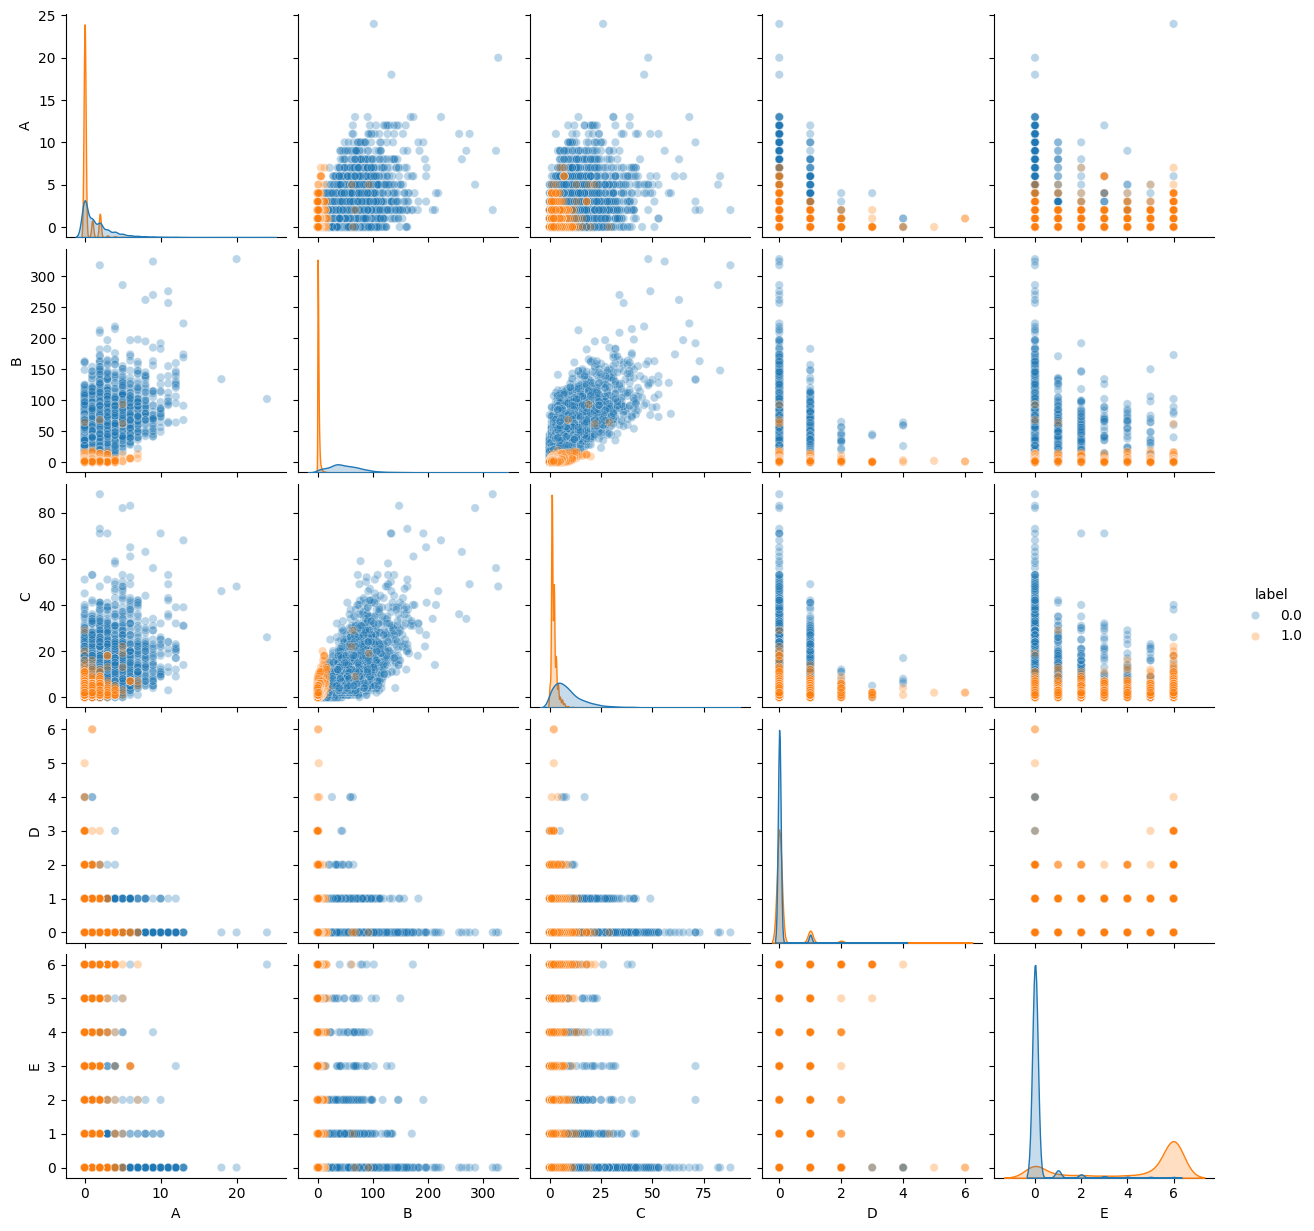

In [ ]:
# Crear una matriz de gráficos de dispersión (pairplot)
import seaborn as sns
import matplotlib.pyplot as plt

# Se eligen las variables numéricas originales para mejorar legibilidad
cols_pairplot = ['A', 'B', 'C', 'D', 'E', 'label']

sns.pairplot(data[cols_pairplot], hue='label', diag_kind='kde', plot_kws={"alpha": 0.3})
plt.show()

In [ ]:
# Eliminar columnas que empiecen por 'Valor_' y la columna 'comentario'
cols_valor = [col for col in data.columns if col.startswith('Valor_')]
cols_a_eliminar = cols_valor + ['comentario']

data_reduced = data.drop(columns=cols_a_eliminar)

# Mostrar las primeras filas del nuevo dataframe para verificar
data_reduced.head()

,A,B,C,D,E,label,A_t,B_t,C_t,D_t,E_t
0,2,64,30,0,2,0.0,1.851102,2.759647,7.145831,-0.416577,0.440638
1,4,70,21,0,0,0.0,3.990202,3.054765,4.877255,-0.416577,-0.531099
2,4,88,50,0,0,0.0,3.990202,3.940120,12.187108,-0.416577,-0.531099
3,3,38,21,0,0,0.0,2.920652,1.480801,4.877255,-0.416577,-0.531099
4,0,59,17,0,0,0.0,-0.287998,2.513715,3.869000,-0.416577,-0.531099


In [ ]:
# Estandarizar las columnas, excepto 'label'
from sklearn.preprocessing import StandardScaler

# Columnas a estandarizar
feature_cols = data_reduced.columns.drop('label')

scaler = StandardScaler()

# Copia para no modificar el dataframe original
data_scaled = data_reduced.copy()
data_scaled[feature_cols] = scaler.fit_transform(data_reduced[feature_cols])

# Ver las primeras filas para comprobar
data_scaled.head()

,A,B,C,D,E,label,A_t,B_t,C_t,D_t,E_t
0,0.598584,1.114413,3.324603,-0.258895,-0.073497,0.0,0.598584,1.114413,3.324603,-0.258895,-0.073497
1,1.746837,1.290828,2.094554,-0.258895,-0.806272,0.0,1.746837,1.290828,2.094554,-0.258895,-0.806272
2,1.746837,1.820075,6.058045,-0.258895,-0.806272,0.0,1.746837,1.820075,6.058045,-0.258895,-0.806272
3,1.172711,0.349946,2.094554,-0.258895,-0.806272,0.0,1.172711,0.349946,2.094554,-0.258895,-0.806272
4,-0.549669,0.967400,1.547866,-0.258895,-0.806272,0.0,-0.549669,0.967400,1.547866,-0.258895,-0.806272


In [ ]:
# Separar las características y las etiquetas
X = data_scaled[feature_cols]
y = data_scaled['label']

# Comprobar formas de X e y
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (10000, 10)
Forma de y: (10000,)


### PCA

In [ ]:
# Aplicar PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Crear un DataFrame con los resultados de PCA
df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'label': y.reset_index(drop=True)
})

df_pca.head()


,PC1,PC2,label
0,3.863271,0.257069,0.0
1,4.253772,0.127813,0.0
2,7.663432,0.736383,0.0
3,3.115034,0.001730,0.0
4,2.094273,-0.313390,0.0


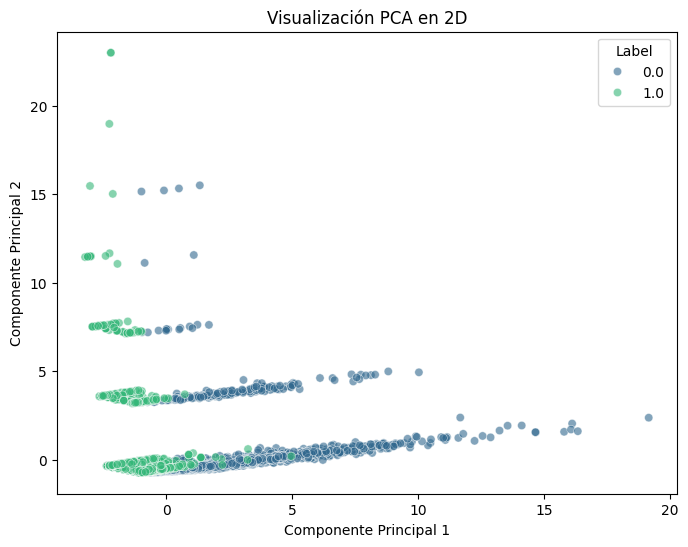

In [ ]:
# Visualizar los resultados de PCA

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='label',
    palette='viridis',
    alpha=0.6
)
plt.title('Visualización PCA en 2D')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Label')
plt.show()

El gráfico PCA en 2D muestra la proyección de los datos en los dos componentes principales. Se observa que las clases 0 y 1 aparecen mezcladas especialmente a lo largo del Componente Principal 1. Aunque existen zonas donde algunos puntos de una clase predominan más que la otra, no hay una separación lineal clara entre ambas clases.

In [ ]:
# Dividir los datos en conjunto de entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,
    stratify=y
)

print("Forma de X_train:", X_train.shape)
print("Forma de X_test :", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test :", y_test.shape)

# Entrenar un modelo de clasificación (por ejemplo, RandomForest)
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

# Predecir y evaluar el modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification report:")
print(classification_report(y_test, y_pred))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Forma de X_train: (8000, 10)
Forma de X_test : (2000, 10)
Forma de y_train: (8000,)
Forma de y_test : (2000,)
Accuracy: 0.9805

Classification report:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1000
         1.0       0.98      0.98      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000

Matriz de confusión:
[[978  22]
 [ 17 983]]


# Analice los resultados obtenidos por PCA

Los resultados de PCA muestran que, al reducir los datos en dos componentes principales, la estructura del conjunto muestra las clases 0 y 1 mezcladas. El modelo RandomForest llega a obtener un accuracy de 98 % lo que sugiere que las clases son separables en el espacio original de 10 dimensiones.

### t-SNE

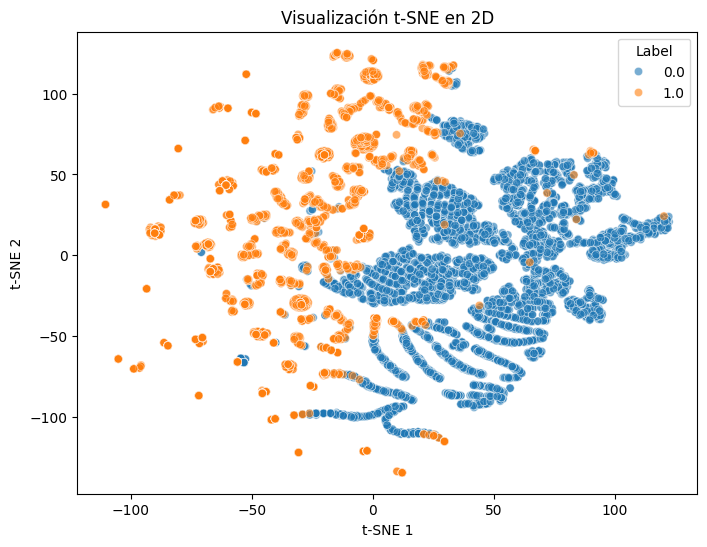

In [ ]:
# Aplicar t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X)

# Crear un DataFrame con los resultados de t-SNE

df_tsne = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'label': y.reset_index(drop=True)
})

df_tsne.head()

# Visualizar los resultados de t-SNE
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_tsne,
    x='TSNE1',
    y='TSNE2',
    hue='label',
    alpha=0.6
)
plt.title('Visualización t-SNE en 2D')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Label')
plt.show()

#### Analice los resultados obtenidos por t-SNE

La gráfica nos muestra una separación mucho más clara entre las clases que la lograda con PCA. Aunque existe una ligera zona donde se sobreponen entre ambos grupos, la mayoría de los datos forman regiones dominadas por una sola clase. Esto indica que t-SNE captura relaciones no lineales entre las características que PCA no pudo reflejar y por tanto logra representar de manera más efectiva la estructura del dataset en dos dimensiones. Por lo tanto t-SNE es más adecuado que PCA.

### Utilizar t-SNE para clasificar

In [ ]:
# Dividir los datos en conjunto de entrenamiento y prueba
X_tsne = df_tsne[['TSNE1', 'TSNE2']]
y_tsne = df_tsne['label']

X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(
    X_tsne,
    y_tsne,
    test_size=0.2,
    random_state=42,
    stratify=y_tsne
)

print("Forma de X_train_tsne:", X_train_tsne.shape)
print("Forma de X_test_tsne :", X_test_tsne.shape)
print("Forma de y_train_tsne:", y_train_tsne.shape)
print("Forma de y_test_tsne :", y_test_tsne.shape)

# Entrenar un modelo de clasificación (por ejemplo, RandomForest)
from sklearn.ensemble import RandomForestClassifier

rf_tsne = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_tsne.fit(X_train_tsne, y_train_tsne)
# Predecir y evaluar el modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_tsne = rf_tsne.predict(X_test_tsne)

acc_tsne = accuracy_score(y_test_tsne, y_pred_tsne)
print(f"Accuracy con características t-SNE: {acc_tsne:.4f}\n")

print("Classification report (t-SNE):")
print(classification_report(y_test_tsne, y_pred_tsne))

print("Matriz de confusión (t-SNE):")
print(confusion_matrix(y_test_tsne, y_pred_tsne))

Forma de X_train_tsne: (8000, 2)
Forma de X_test_tsne : (2000, 2)
Forma de y_train_tsne: (8000,)
Forma de y_test_tsne : (2000,)
Accuracy con características t-SNE: 0.9835

Classification report (t-SNE):
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      1000
         1.0       0.98      0.99      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000

Matriz de confusión (t-SNE):
[[978  22]
 [ 11 989]]


#### ¿Se puede utilizar la reducción de dimensinalidad obtenida por t-SNE para entrenar un algoritmo de clasificación?

Sí, se puede utilizar la reducción de dimensionalidad obtenida por t-SNE para entrenar un algoritmo de clasificación, sin embargo no es lo ideal en la práctica. Esto se debe a que t-SNE no fue diseñado para ser un método de transformación reproducible para modelos predictivos, sino para visualización y exploración de datos.

### LDA

In [ ]:
# Descargar las palabras vacías en español
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
spanish_stopwords = stopwords.words('spanish')
comentarios = data['comentario'].fillna('').astype(str)

comentarios = comentarios.str.lower()
comentarios = data['comentario'].fillna('').astype(str)
# Aplicar LDA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Vectorizar los comentarios en bolsa de palabras
vectorizer = CountVectorizer(
    stop_words=spanish_stopwords,
    max_df=0.95,
    min_df=5
)

X_bow = vectorizer.fit_transform(comentarios)

# Definir y ajustar el modelo LDA en este caso para 5
n_topics = 5
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42
)

lda.fit(X_bow)
# Mostrar los temas
feature_names = vectorizer.get_feature_names_out()

def mostrar_temas(model, feature_names, n_top_words=10):
    for idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"Tema {idx}: {' '.join(top_words)}")

mostrar_temas(lda, feature_names, n_top_words=10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Tema 0: mas poder año hacer tambien ser cientifico estudio persona investigador
Tema 1: mas poder hacer ser tambien año decir vez solo tiempo
Tema 2: año mas obra ser hacer tambien primero artista libro arte
Tema 3: mas gobierno poder año hacer tambien nuevo ser españa millón
Tema 4: dia año mas hacer ser hoy abc poder dos hora


Preprocesamiento: Este paso convierte el texto en una matriz de términos.
Aplicación de LDA: Ejecuta el algoritmo LDA para encontrar los temas.
Visualización de Temas: Imprime los temas encontrados con las palabras más representativas.

### LDA en función del label

In [ ]:
# Descargar las palabras vacías en español
nltk.download('stopwords')
spanish_stopwords = stopwords.words('spanish')

# Definir función para aplicar LDA y obtener temas
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd

def obtener_temas_lda(textos, n_topics=5, top_words=10):
    vectorizer = CountVectorizer(
        stop_words=spanish_stopwords,
        max_df=0.95,
        min_df=5
    )
    X_bow = vectorizer.fit_transform(textos)
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda.fit(X_bow)

    feature_names = vectorizer.get_feature_names_out()
    temas = []
    for idx, topic in enumerate(lda.components_):
        palabras_idx = topic.argsort()[:-top_words - 1:-1]
        palabras = [feature_names[i] for i in palabras_idx]
        temas.append({"tema": idx, "palabras": ", ".join(palabras)})

    return pd.DataFrame(temas)
# Aplicar LDA por cada etiqueta de label y guardar en archivos CSV
    # Crear un DataFrame para los temas

for etiqueta in data['label'].unique():
    subset = data[data['label'] == etiqueta]['comentario'].fillna('').astype(str)

    df_temas = obtener_temas_lda(subset, n_topics=5, top_words=10)

    # Guardar el DataFrame en un archivo CSV
    nombre_archivo = f"temas_label_{int(etiqueta)}.csv"
    df_temas.to_csv(nombre_archivo, index=False)
    print(f"Archivo guardado: {nombre_archivo}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Archivo guardado: temas_label_0.csv
Archivo guardado: temas_label_1.csv


In [ ]:
# Generar bolsas de palabras para cada tema
vectorizer_all = CountVectorizer(
    stop_words=spanish_stopwords,
    max_df=0.95,
    min_df=5
)

X_bow_all = vectorizer_all.fit_transform(data['comentario'].fillna('').astype(str))

lda_all = LatentDirichletAllocation(
    n_components=5,   # mismo número de temas usado antes
    random_state=42
)

lda_all.fit(X_bow_all)

feature_names_all = vectorizer_all.get_feature_names_out()

def top_words_topic(model, feature_names, n_top=12):
    topics = []
    for idx, topic in enumerate(model.components_):
        indices = topic.argsort()[:-n_top - 1:-1]
        words = [feature_names[i] for i in indices]
        topics.append(words)
    return topics

temas_globales = top_words_topic(lda_all, feature_names_all)
temas_globales
# Asignar temas a comentarios
topic_distribution = lda_all.transform(X_bow_all)
tema_asignado = topic_distribution.argmax(axis=1)

data['tema_predicho'] = tema_asignado
data.head()
# Generar bolsas de palabras para cada etiqueta
bolsa_por_etiqueta = data.groupby('label')['tema_predicho'].value_counts().unstack().fillna(0)
bolsa_por_etiqueta
# Asignar temas a comentarios y comparar con etiquetas reales
tabla_comparacion = pd.crosstab(data['label'], data['tema_predicho'])
tabla_comparacion
# Comparar temas asignados con etiquetas reales
tabla_comparacion_pct = tabla_comparacion.div(tabla_comparacion.sum(axis=1), axis=0) * 100
tabla_comparacion_pct

tema_predicho,0,1,2,3,4
label,,,,,
0.0,16.96,22.08,20.36,22.22,18.38
1.0,4.04,11.82,4.08,4.82,75.24


La comparación entre los temas asignados por LDA y las etiquetas muestran una relación clara entre la estructura semántica de los comentarios y la clasificación del dataset. En la clase 0 los temas están distribuidos de manera equilibrada entre las cinco categorías, lo que sugiere una mayor diversidad temática en ese grupo. En cambio, en la clase 1 se observa una concentración marcada en el tema 4, con más del 75 % de sus comentarios asignados a ese tópic, lo que indica que esta clase contiene un patrón lingüístico dominante que LDA fue capaz de capturar.